In [ ]:
!pip install diffusers
!pip install transformers
!pip install accelerate
!pip install matplotlib

import os
import torch
import torch.nn.functional as F

from torch.utils.data import Dataset, DataLoader

from torchvision import transforms

from PIL import Image

import matplotlib.pyplot as plt

from diffusers import (
    UNet2DModel,
    DDPMScheduler
)

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os

dataset_path = "/content/drive/MyDrive/MRI_Project/MRI_Reconstruction/better_slices"

print(os.listdir(dataset_path)[:10])

Mounted at /content/drive
['slice_578.png', 'slice_604.png', 'slice_601.png', 'slice_592.png', 'slice_616.png', 'slice_3529.png', 'slice_588.png', 'slice_618.png', 'slice_614.png', 'slice_568.png']


CREATE CONDITIONAL MRI DATASET

In [ ]:
class ConditionalMRIDataset(Dataset):

    def __init__(self, folder_path):

        self.folder_path = folder_path

        self.image_files = [
            os.path.join(folder_path, file)
            for file in os.listdir(folder_path)
            if file.endswith(".png")
        ]

        self.transform = transforms.Compose([

            transforms.Grayscale(),

            transforms.Resize((128,128)),

            transforms.ToTensor(),

            transforms.Normalize(
                [0.5],
                [0.5]
            )
        ])

    def add_motion_artifact(self, image, severity=1.0):
    kspace = torch.fft.fft2(image)

    num_corrupted = int(0.3 * severity * kspace.shape[-2])
    lines = torch.randperm(kspace.shape[-2])[:num_corrupted]
    kspace[:, lines, :] += torch.randn_like(kspace[:, lines, :]) * 0.8 * severity

    corrupted = torch.fft.ifft2(kspace).real
    corrupted = corrupted + torch.randn_like(corrupted) * 0.15 * severity

    return torch.clamp(corrupted, -1, 1)

def __getitem__(self, idx):
    image = Image.open(self.image_files[idx])
    clean_image = self.transform(image)

    corrupted_image = self.add_motion_artifact(clean_image, severity=1.0)   # heavy input
    target_image    = self.add_motion_artifact(clean_image, severity=0.35) # mild residual — what stage 1 should output

    return corrupted_image, target_image

CREATE DATASET + DATALOADER and VISUALIZE DATA

Dataset Ready: 5599


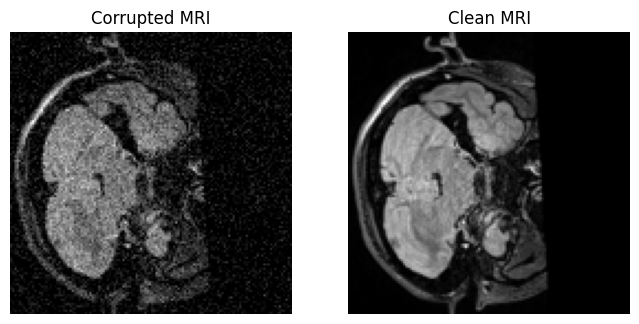

In [ ]:
dataset = ConditionalMRIDataset(
    dataset_path
)

dataloader = DataLoader(
    dataset,
    batch_size=8,
    shuffle=True
)

print(
    "Dataset Ready:",
    len(dataset)
)



corrupted, clean = dataset[0]

fig, ax = plt.subplots(
    1,
    2,
    figsize=(8,4)
)

ax[0].imshow(
    corrupted.squeeze(),
    cmap="gray"
)

ax[0].set_title(
    "Corrupted MRI"
)

ax[0].axis("off")

ax[1].imshow(
    clean.squeeze(),
    cmap="gray"
)

ax[1].set_title(
    "Clean MRI"
)

ax[1].axis("off")

plt.show()

CREATE CONDITIONAL U-NET + NOISE SCHEDULER + OPTIMIZER

In [ ]:
model = UNet2DModel(

    sample_size=128,

    in_channels=2,
    out_channels=1,

    layers_per_block=2,

    block_out_channels=(64, 128, 256, 256),
down_block_types=(
    "DownBlock2D",
    "DownBlock2D",
    "AttnDownBlock2D",
    "DownBlock2D",
),
up_block_types=(
    "UpBlock2D",
    "AttnUpBlock2D",
    "UpBlock2D",
    "UpBlock2D",
),
)

model = model.to("cuda")


noise_scheduler = DDPMScheduler(
    num_train_timesteps=1000
)


optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-4
)

CONDITIONAL TRAINING LOOP

In [ ]:
checkpoint_path = "/content/drive/MyDrive/MRI_Project/MRI_Reconstruction/conditional_mri_checkpoint.pth"

start_epoch = 0

if os.path.exists(checkpoint_path):

    print("Loading checkpoint...")

    checkpoint = torch.load(checkpoint_path)

    model.load_state_dict(
        checkpoint['model_state_dict']
    )

    optimizer.load_state_dict(
        checkpoint['optimizer_state_dict']
    )

    start_epoch = checkpoint['epoch'] + 1

    print(
        f"Resuming from epoch {start_epoch}"
    )

else:

    print("No checkpoint found. Starting fresh.")

Loading checkpoint...
Resuming from epoch 17


In [ ]:
epochs = 20

model.train()

for epoch in range(start_epoch, epochs):
    print(f"\nEpoch {epoch+1}/{epochs}")
    epoch_loss = 0.0

    for step, (corrupted_images, clean_images) in enumerate(dataloader):
        corrupted_images = corrupted_images.to("cuda")
        clean_images     = clean_images.to("cuda")

        noise     = torch.randn_like(clean_images)
        timesteps = torch.randint(0, 1000, (clean_images.shape[0],),
                                  device=clean_images.device).long()

        noisy_images = noise_scheduler.add_noise(clean_images, noise, timesteps)
        model_input  = torch.cat([noisy_images, corrupted_images], dim=1)
        noise_pred   = model(model_input, timesteps).sample

        loss = F.mse_loss(noise_pred, noise)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    avg_loss = epoch_loss / len(dataloader)
    print(f"Epoch {epoch+1} | Avg Loss: {avg_loss:.4f}")

    # Save checkpoint every epoch
    torch.save({
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
    }, checkpoint_path)
    print(f"  Checkpoint saved")


Epoch 18/20
Epoch 18 | Avg Loss: 0.0114
  Checkpoint saved

Epoch 19/20
Epoch 19 | Avg Loss: 0.0101
  Checkpoint saved

Epoch 20/20
Epoch 20 | Avg Loss: 0.0107
  Checkpoint saved


THE TRAINING PROCESS IS COMPLETED, NOW WE EVELUATE THE MODEL'S PERFORMANCE

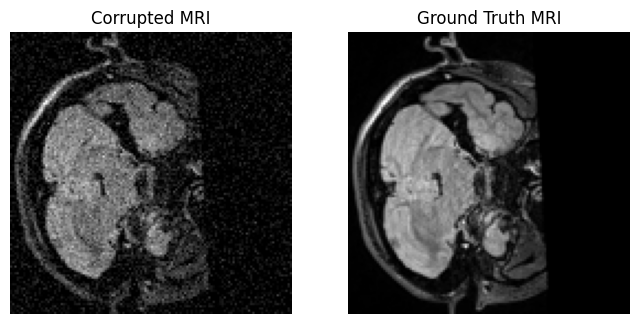

In [ ]:
model.eval()


corrupted_image, clean_image = dataset[0]


fig, ax = plt.subplots(
    1,
    2,
    figsize=(8,4)
)

ax[0].imshow(
    corrupted_image.squeeze(),
    cmap="gray"
)

ax[0].set_title(
    "Corrupted MRI"
)

ax[0].axis("off")

ax[1].imshow(
    clean_image.squeeze(),
    cmap="gray"
)

ax[1].set_title(
    "Ground Truth MRI"
)

ax[1].axis("off")

plt.show()

INFERENCE


In [ ]:
from diffusers import DDIMScheduler

model.eval()

corrupted_image, clean_image = dataset[0]
corrupted_input = corrupted_image.unsqueeze(0).to("cuda")   # [1, 1, 128, 128]

# DDIM scheduler for fast inference
inference_scheduler = DDIMScheduler(num_train_timesteps=1000)
inference_scheduler.set_timesteps(200)

# Start from corrupted image + slight noise at t=200
noise = torch.randn_like(corrupted_input)
x = noise_scheduler.add_noise(
    corrupted_input,
    noise,
    torch.tensor([200], device="cuda")
)

# Iterative denoising loop — concatenate corrupted image every step
timesteps_to_use = [t for t in inference_scheduler.timesteps if t <= 200]

with torch.no_grad():
    for t in timesteps_to_use:
        t_batch     = torch.tensor([t], device="cuda")
        model_input = torch.cat([x, corrupted_input], dim=1)  # [1, 2, 128, 128]
        noise_pred  = model(model_input, t_batch).sample
        x           = inference_scheduler.step(noise_pred, t, x).prev_sample

# Denormalize to [0, 1] for display
reconstructed = (x.squeeze().cpu().numpy() * 0.5) + 0.5

VISUALIZATION OF THE RESULT

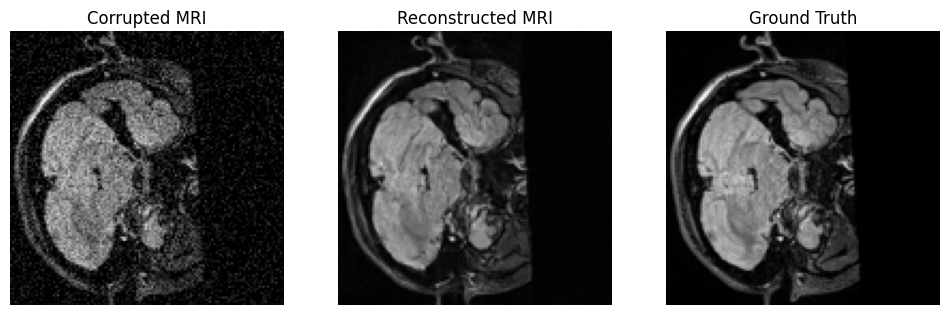

In [ ]:
fig, ax = plt.subplots(
    1,
    3,
    figsize=(12,4)
)

ax[0].imshow(
    corrupted_image.squeeze(),
    cmap="gray"
)

ax[0].set_title(
    "Corrupted MRI"
)

ax[0].axis("off")

ax[1].imshow(
    reconstructed,
    cmap="gray"
)

ax[1].set_title(
    "Reconstructed MRI"
)

ax[1].axis("off")

ax[2].imshow(
    clean_image.squeeze(),
    cmap="gray"
)

ax[2].set_title(
    "Ground Truth"
)

ax[2].axis("off")

plt.show()

MATHEMATICAL EVALUATION OF THE MODEL

In [ ]:
!pip install scikit-image


In [ ]:
from skimage.metrics import (
    mean_squared_error,
    peak_signal_noise_ratio,
    structural_similarity
)

In [ ]:
import numpy as np
from skimage.metrics import mean_squared_error, peak_signal_noise_ratio, structural_similarity

# clean_image is in [-1, 1] — normalize to [0, 1]
ground_truth = (clean_image.squeeze().numpy() * 0.5) + 0.5
ground_truth = np.clip(ground_truth, 0, 1)

# reconstructed is already in [0, 1] — just clip
reconstructed_eval = np.clip(reconstructed.squeeze(), 0, 1)

mse_value  = mean_squared_error(ground_truth, reconstructed_eval)
psnr_value = peak_signal_noise_ratio(ground_truth, reconstructed_eval, data_range=1.0)
ssim_value = structural_similarity(ground_truth, reconstructed_eval, data_range=1.0)

print(f"MSE  : {mse_value:.4f}")
print(f"PSNR : {psnr_value:.4f}")
print(f"SSIM : {ssim_value:.4f}")

MSE  : 0.0017
PSNR : 27.7987
SSIM : 0.6497
